# Optimize each one with the found initial parameters

In [4]:
import autograd.numpy as np 
import matplotlib.pyplot as plt

import tidy3d as td
import tidy3d.web as web

import json

from main import (make_sim, get_coupling_efficiency, projection_builder, run_adam, apodized_to_widths,
                    R, r0, initial_fill_factor, grating_period, 
                    etch_depth, to_substrate, N_teeth, n_wl, wl_range,
                    to_substrate)


In [50]:
def objective(params,projection=None):
    params_proj = projection(params)
    widths = params_proj[:N_teeth*2+2]
    r0 = params_proj[N_teeth*2+2]
    etch_depth = params_proj[N_teeth*2+3]
    to_substrate = params_proj[N_teeth*2+4]
    
    sim = make_sim(widths, r0=r0, etch_depth=etch_depth, to_substrate=to_substrate, min_steps_per_wvl=30)
    sim_data = web.run(sim, task_name="GC4um_2D_initial_opt", verbose=False)
    return sim,get_coupling_efficiency(sim_data),sim_data#[n_wl//2]

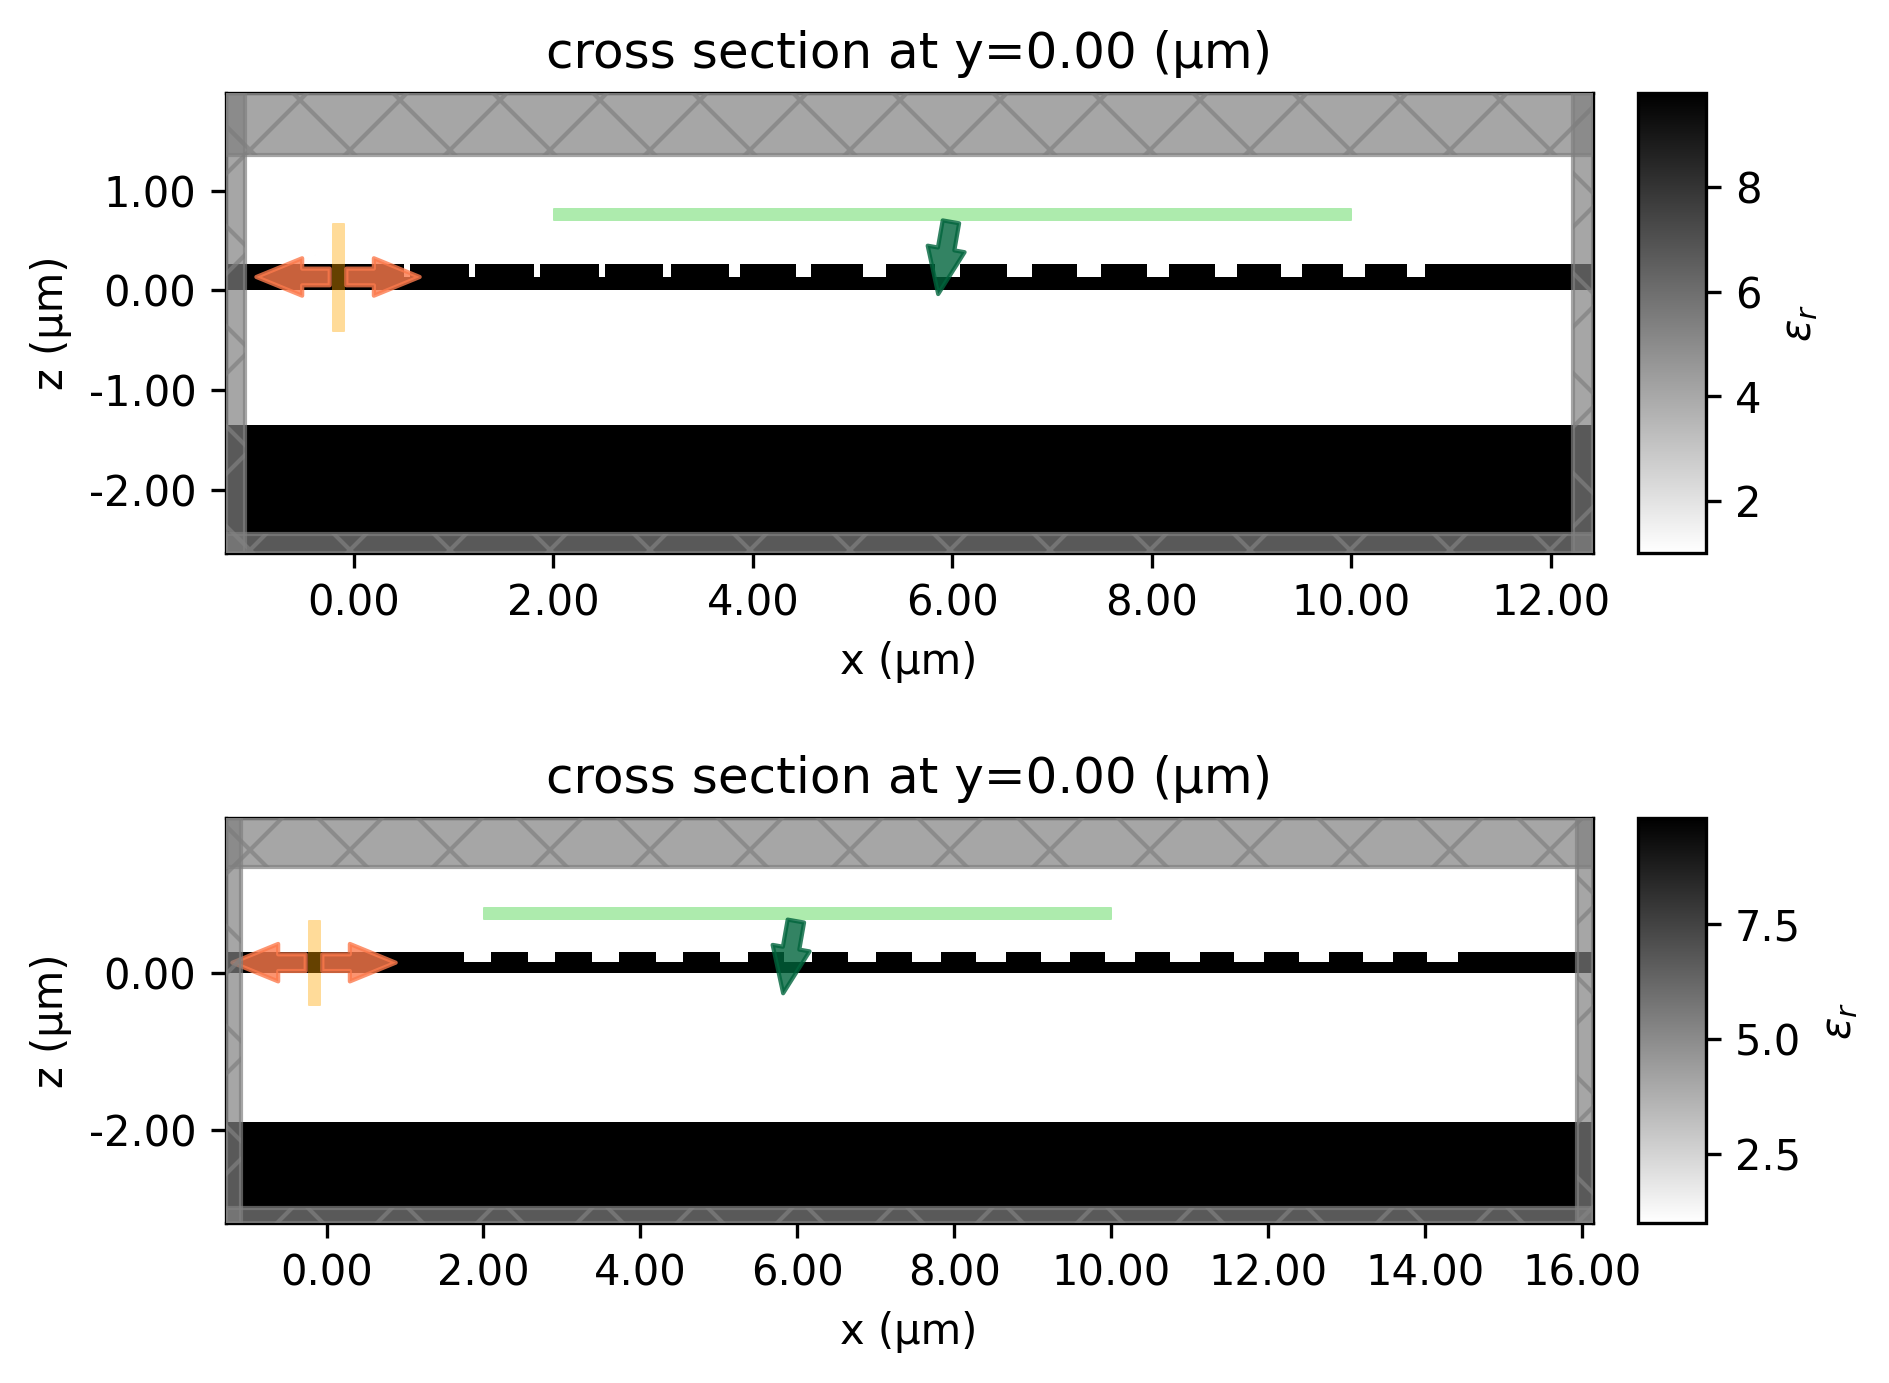

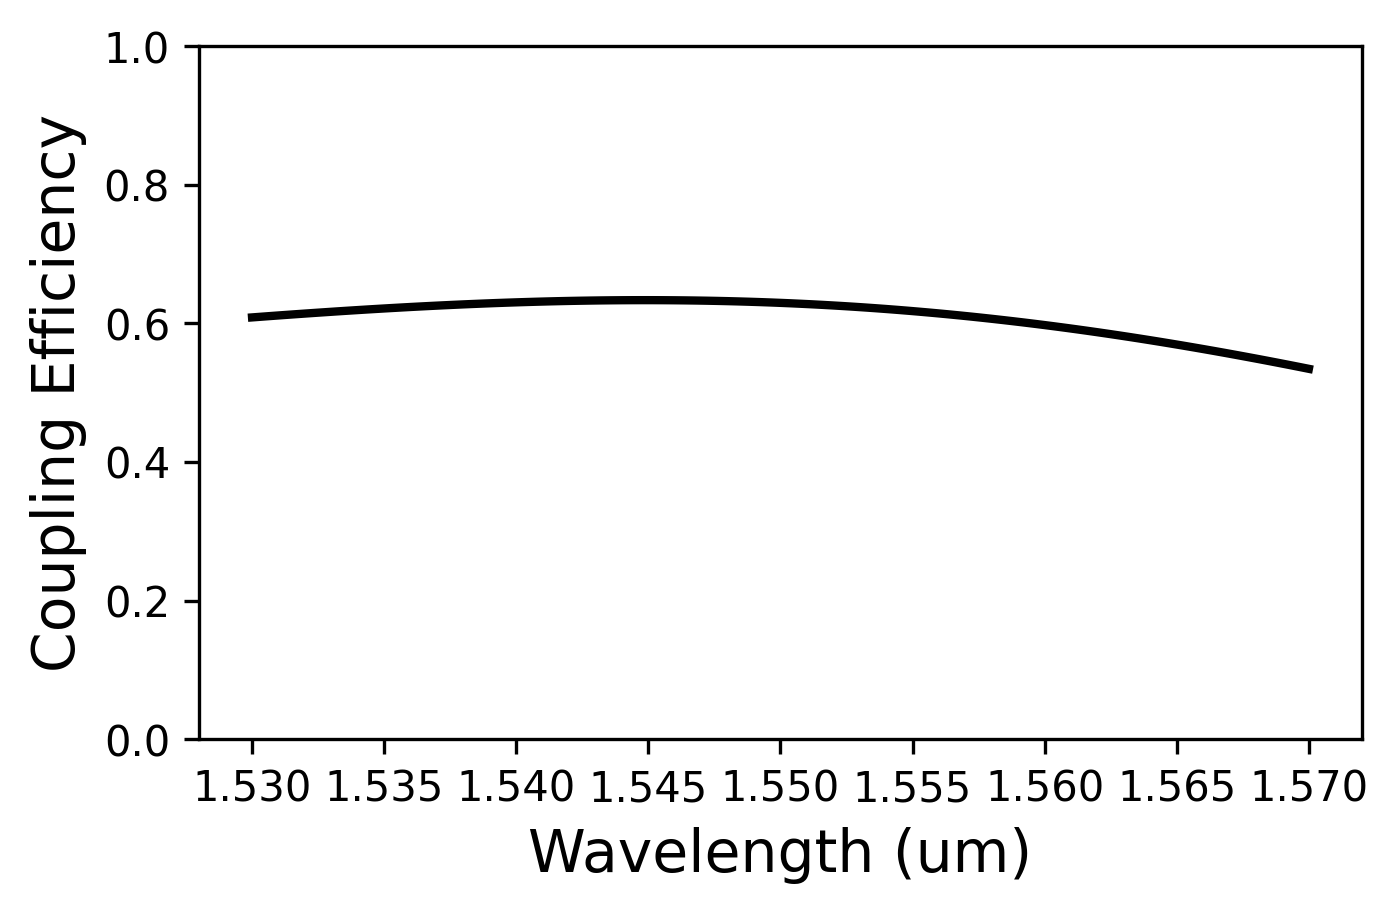

In [53]:
widths = apodized_to_widths(R=R, initial_fill_factor=initial_fill_factor)
params0 = np.concatenate([widths, [r0], [etch_depth], [to_substrate]])
with open('/Users/dominic/Desktop/fdtd/testing/PhotonicComponents/GC_4um_2D/data/initial_opt_50nm.json', 'r') as f:
    history = json.load(f)
paramsfinal = history["params"][-1]
params0 = history["params"][0]
project, inverse_project = projection_builder()

#sim,obj,sim_data = objective(paramsfinal,projection=project)
#sim0,obj0,sim_data0 = objective(project(params0),projection=project)
fig,ax = plt.subplots(2,1,dpi=300)
sim.plot_eps(y=0,ax=ax[0])
sim0.plot_eps(y=0,ax=ax[1])
plt.tight_layout()
plt.show()
# sim_data.plot_field("field", "E", "abs^2", y=0)
# plt.show()
plt.figure(figsize=(5,3),dpi=300)
plt.plot(wl_range,obj,linewidth=2,color="black")
#plt.plot(wl_range,obj0,linewidth=2,color="red")
plt.ylim(0,1)
plt.ylabel("Coupling Efficiency",fontsize=14)
plt.xlabel("Wavelength (um)",fontsize=14)
plt.show()


In [54]:
print(project(paramsfinal))

[0.0537495  0.59640411 0.05666614 0.59271736 0.0595468  0.58880725
 0.06256962 0.5847134  0.07603799 0.5811734  0.11060108 0.55837934
 0.15157565 0.52626121 0.22921975 0.49418847 0.25175105 0.46699969
 0.25146523 0.44902982 0.23924241 0.46789355 0.21745444 0.46331741
 0.2147066  0.44152572 0.21001051 0.41603742 0.22290763 0.41428054
 0.1812964  0.394875   0.5059945  0.13658682 1.34870168]


## Start with the 50um mimimum

In [ ]:
widths = apodized_to_widths(R=R, initial_fill_factor=initial_fill_factor)
params0 = np.concatenate([widths, [r0], [etch_depth], [to_substrate]])
#params0 = project(history["params"][-1])
project, inverse_project = projection_builder()

history, opt_state = run_adam(params0, project, inverse_project, objective, num_steps=35, learning_rate=0.01, verbose=True)

KeyboardInterrupt: 

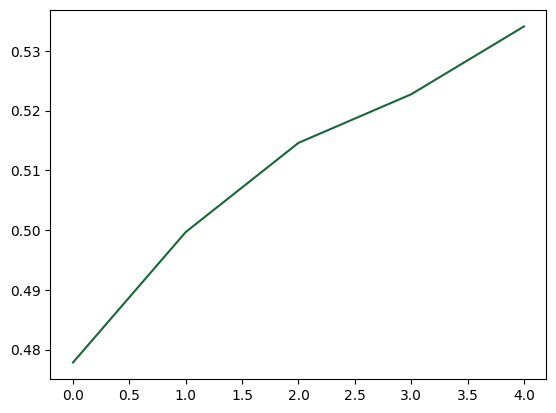

In [12]:

plt.plot(history["J"])
plt.show()

In [48]:
project, inverse_project = projection_builder()
params = project(history["params"][-1])
widths = params[:N_teeth*2+2]
r0 = params[N_teeth*2+2]
etch_depth = params[N_teeth*2+3]
to_substrate = params[N_teeth*2+4]

sim = make_sim(widths, r0=r0, etch_depth=etch_depth, to_substrate=to_substrate, include_field_monitor=True)
sim_data = web.run(sim, task_name="GC4um50nm_2D_final_opt", verbose=False)
ce = get_coupling_efficiency(sim_data)

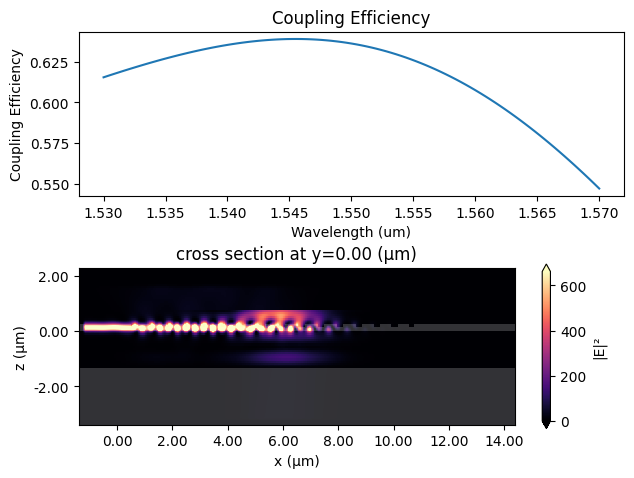

In [ ]:
fig,ax = plt.subplots(2,1)
ax[0].plot(wl_range, ce)
ax[0].set_xlabel("Wavelength (um)")
ax[0].set_ylabel("Coupling Efficiency")
ax[0].set_title("Coupling Efficiency")
sim_data.plot_field("field", "E", "abs^2", y=0, ax=ax[1])
plt.tight_layout()
plt.show()

In [56]:
# Save the optimization history to disk in a human-readable JSON file.
with open("data/initial_opt_50nm.json", "w") as f:
    json.dump(history, f, indent=2)

## Now lets do it for the minimum size of 100 nm

In [113]:
# R100 = 0.02
# initial_fill_factor100 = 120/650
# r0100 = 1.0
# etch_depth100 = 0.087
# to_substrate100 = 1.210

# widths_bounds100 = (0.1,0.55)

# widths100 = apodized_to_widths(R=R100, initial_fill_factor=initial_fill_factor100)
# params0100 = np.concatenate([widths100, [r0100], [etch_depth100], [to_substrate100]])
# project100, inverse_project100 = projection_builder(widths_bounds=widths_bounds100)

history100, opt_state = run_adam(project100(np.array(history100["params"][-1])), project100, inverse_project100, objective, num_steps=50, learning_rate=0.02, verbose=True, history=history100, opt_state=opt_state)

step = 1
	J = 5.302e-01
	grad_norm = 9.1242e+01
step = 2
	J = 5.328e-01
	grad_norm = 8.5364e+01
step = 3
	J = 5.333e-01
	grad_norm = 3.5042e+02
step = 4
	J = 5.338e-01
	grad_norm = 1.4571e+02
step = 5
	J = 5.351e-01
	grad_norm = 5.8768e+01
step = 6
	J = 5.358e-01
	grad_norm = 3.8662e+02
step = 7
	J = 5.367e-01
	grad_norm = 3.6957e+02
step = 8
	J = 5.370e-01
	grad_norm = 3.0651e+02
step = 9
	J = 5.381e-01
	grad_norm = 1.3988e+02
step = 10
	J = 5.394e-01
	grad_norm = 1.0690e+02
step = 11
	J = 5.402e-01
	grad_norm = 3.3128e+02
step = 12
	J = 5.403e-01
	grad_norm = 9.8034e+01
step = 13
	J = 5.413e-01
	grad_norm = 2.7315e+02
step = 14
	J = 5.418e-01
	grad_norm = 2.8892e+02
step = 15
	J = 5.420e-01
	grad_norm = 3.1791e+02
step = 16
	J = 5.424e-01
	grad_norm = 1.2015e+02
step = 17
	J = 5.430e-01
	grad_norm = 3.1288e+02
step = 18
	J = 5.437e-01
	grad_norm = 2.9990e+02
step = 19
	J = 5.436e-01
	grad_norm = 1.6828e+02
step = 20
	J = 5.446e-01
	grad_norm = 1.6793e+02
step = 21
	J = 5.446e-01
	gra

In [ ]:
params_proj = project100(history100["params"][-1])
widths = params_proj[:N_teeth*2+2]
r0 = params_proj[N_teeth*2+2]
etch_depth = params_proj[N_teeth*2+3]
to_substrate = params_proj[N_teeth*2+4]
    
sim = make_sim(widths, r0=r0, etch_depth=etch_depth, to_substrate=to_substrate, include_field_monitor=True)
sim_data = web.run(sim, task_name="GC4um_2D_initial_opt", folder_name="dominic", verbose=False)

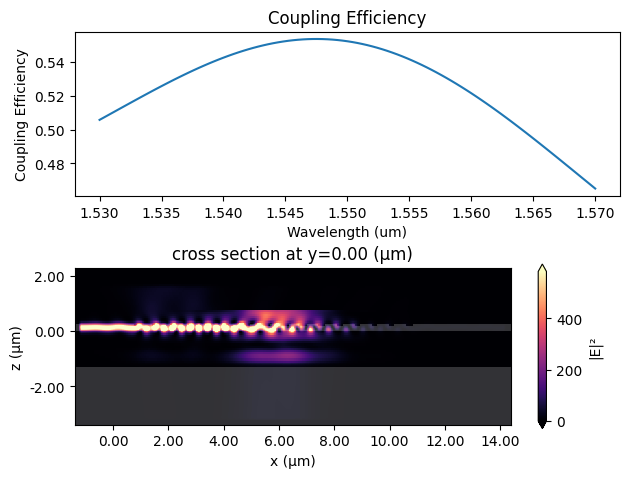

In [122]:
ce100 = get_coupling_efficiency(sim_data)
fig,ax = plt.subplots(2,1)
ax[0].plot(wl_range, ce100)
ax[0].set_xlabel("Wavelength (um)")
ax[0].set_ylabel("Coupling Efficiency")
ax[0].set_title("Coupling Efficiency")
sim_data.plot_field("field", "E", "abs^2", y=0, ax=ax[1])
plt.tight_layout()
plt.show()

In [124]:
# Save the optimization history to disk in a human-readable JSON file.
with open("data/initial_opt_100nm.json", "w") as f:
    json.dump(history100, f, indent=2)